# Decision Tree Classifier from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

A **Decision Tree** is a non-parametric supervised learning algorithm that splits data recursively based on feature values to maximize **information gain**. Each internal node represents a test on a feature, each branch represents an outcome, and each leaf represents a class label.

We use **entropy** to measure impurity and select the best split:

$$H(S) = -\sum_{c} p_c \log_2(p_c)$$

**Information gain** is the reduction in entropy after splitting:

$$IG(S, A) = H(S) - \sum_{v} \frac{|S_v|}{|S|} H(S_v)$$

Decision trees are highly **interpretable** — you can trace any prediction back through the tree.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.decision_tree_classifier import DecisionTreeClassifier
from rice_ml.processing.metrics import accuracy_score, confusion_matrix

## Loading and Exploring the Dataset

We use the **Wine dataset** — 178 wine samples described by 13 chemical features classified into 3 wine cultivars. This is a more complex and realistic benchmark than Iris, with more features and real-world chemical measurements.

Note: Decision trees do **not** require feature scaling because they make splits based on threshold comparisons, not distances.

In [15]:
data = load_wine()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"Feature names: {data.feature_names}")

Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 142
Test samples: 36


## Training the Decision Tree

In [17]:
model = DecisionTreeClassifier(max_depth=5)
print("Training Decision Tree...")
model.fit(X_train, y_train)
print("Training Complete.")

Training Decision Tree...
Training Complete.


## Evaluation

In [18]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

Accuracy: 0.9722

Confusion Matrix:
[[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]


## Comparing Different Tree Depths

Tree depth controls model complexity:
- Shallow tree → high bias, low variance (underfitting)
- Deep tree → low bias, high variance (overfitting)

In [19]:
depths = [1, 2, 3, 5, 7, 10, 15]
train_accs = []
test_accs = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d).fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))
    print(f"Depth {d:2d} | Train = {train_accs[-1]:.4f} | Test = {test_accs[-1]:.4f}")

Depth  1 | Train = 0.5986 | Test = 0.6111
Depth  2 | Train = 0.9577 | Test = 1.0000
Depth  3 | Train = 0.9930 | Test = 1.0000
Depth  5 | Train = 1.0000 | Test = 0.9722
Depth  7 | Train = 1.0000 | Test = 0.9722
Depth 10 | Train = 1.0000 | Test = 0.9722
Depth 15 | Train = 1.0000 | Test = 0.9722


## Visualizing Train vs Test Accuracy

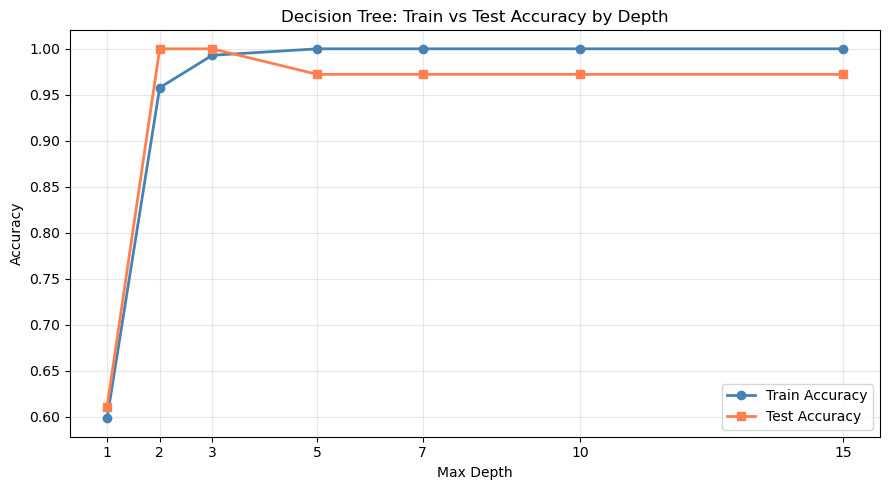

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy',
         color='steelblue', linewidth=2)
plt.plot(depths, test_accs, marker='s', label='Test Accuracy',
         color='coral', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Train vs Test Accuracy by Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

## Decision Boundary Visualization

We visualize the tree's decision boundaries using the first two features.

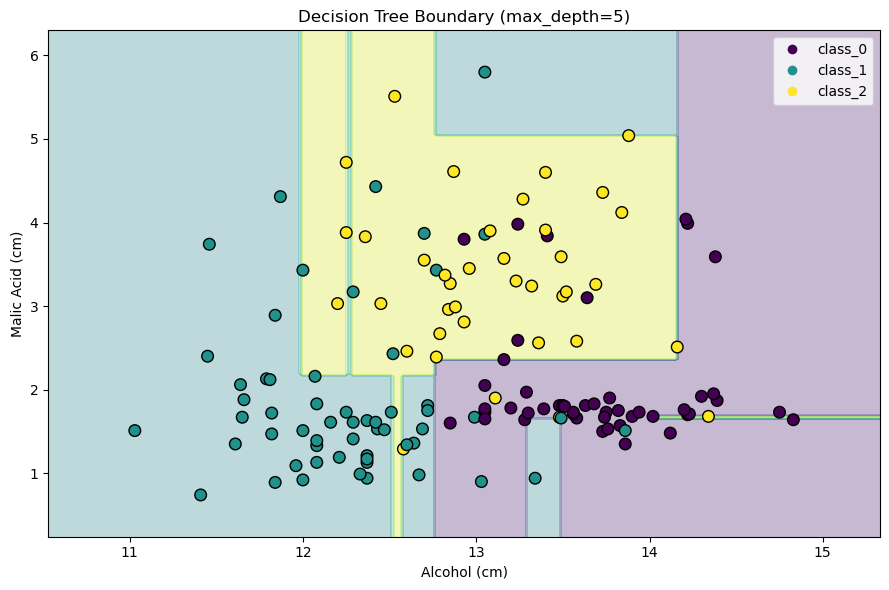

In [21]:
X_2d = X[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = sklearn_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y)

model_2d = DecisionTreeClassifier(max_depth=5).fit(X_train_2d, y_train_2d)

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=y_train_2d, cmap='viridis', edgecolors='k', s=70)
plt.xlabel('Alcohol (cm)')
plt.ylabel('Malic Acid (cm)')
plt.title('Decision Tree Boundary (max_depth=5)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(data.target_names))
plt.tight_layout()
plt.show()

## Discussion

- The Decision Tree achieves **97.22% accuracy** on the Wine dataset, correctly classifying 35 out of 36 test samples with only 1 misclassification
- The confusion matrix shows perfect classification for class_0 and class_2, with only 1 class_1 sample incorrectly predicted as class_0
- The **train vs test accuracy plot** reveals a fascinating pattern unique to this dataset
- At depth 1, both train and test accuracy are low at around 60%, showing clear underfitting
- At depths 2 and 3, test accuracy actually reaches **100%** while train accuracy is still below 100%, which is an unusual and interesting result showing the tree generalizes extremely well at shallow depths
- From depth 5 onwards, train accuracy hits 100% while test accuracy settles at 97.22%, showing mild overfitting where the tree starts memorizing training noise
- The optimal depth for this dataset is **2 or 3**, which is shallower than expected, suggesting the 13 chemical features create very clean natural boundaries between wine cultivars
- The **decision boundary visualization** uses only alcohol and malic acid as the two features, showing characteristic axis-aligned rectangular regions that are the signature of tree-based models
- Alcohol content is clearly the most dominant splitting feature, with class_1 dominating low alcohol ranges, class_2 occupying middle ranges at higher malic acid, and class_0 clustering at higher alcohol levels
- The rectangular boundaries contrast clearly with the perceptron's single diagonal line, showing that decision trees can capture more complex non-linear patterns
- Some small rectangular pockets in the middle alcohol range suggest mild overfitting in that region where class_1 and class_2 overlap
- **Strengths** include no feature scaling required, interpretable splits, and strong performance on datasets with clean chemical boundaries like Wine
- **Weaknesses** include axis-aligned boundaries that struggle with diagonally separated classes, and tendency to overfit at deeper levels
- These weaknesses motivate ensemble methods like Random Forest which combine many trees to reduce variance, as demonstrated in the Ensemble Methods notebook